# <center><b> NLP STARTERS - PART 1 <center/>
    
## <center><b> Tokenization,Vectorization and N-grams<center/>

#### This is an introductory notebook to introduce the NLP concepts, which I'm planning to do in parts ranging from basics like Bag of Words, TFIDF to advanced NLP techniques like attention and transformers

#### <font color='red'> If you like my work, and would want me to continuously put efforts to publish notebooks on NLP, please upvote to boost my morale, and contribute more :)

#### Text data has been prevalent since ages and effectively processing and synthesizing the text data has been an area of research, and till date effective progress is been made in this field, and will continue to do so.

#### Hence if you are new to this field, get ready for the exciting journey of constant learning and experimenting what we learned on the ever increasing text data around us.

## Table of Contents:

* [How's text data different?](#section-one)
* [Making text machine readable](#s2)
    * [Tokenization](#section-two)
    * [N Grams](#section-3)
    * [Vectorization](#s3)
    * [One hot encoding](#section_4)
    * [Count Vectorization / Bag of Words Model](#section-5)
    * [TFIDF Vectorizer](#section-6)

## <b>How's text data different?
<a id="section-one"></a>

#### If you're new to this field you might be wondering how text data is different from tabular data, when it comes to machine learning, and what are the changes we need to make before feeding it to any machine learning model.
    
* #### First of all, <b>machines do not understand characters, words or sentences, all it can understand is numbers</b>
    
![](https://www.convertbinary.com/wp-content/uploads/robots-1024x731.jpg) 
  
#### Hence it becomes absolutely necessary to convert the text into the form it understands, and then make it to learn, more like what we see above!
    
    
    
    
    


* #### Secondly <b>text data is sequential.</b> i.e there is an order in which the words are arranged for us to make sense, if the order is changed, it will not make sense to us
    
#### <font color='blue'>"explain lost can little I'm again that you?"
    
####  The above sentence doesn't make any sense (atleast to me!!) and if you say that to me, I'd be a little lost, while the actual sentence was:
    
#### <font color='blue'>"I'm little lost, can you explain that again?"
    
#### Hence the sequence and order is of importance while processing text. In advanced terms, it is called syntax and semantics of language
    
#### This would come under advanced NLP techniques, and we will discuss that in detail in the upcoming notebooks, however, our first priority is making text machine readable

<a id="s2"></a>
## <b> Making text machine readable!

#### So the first mission of any NLP engineer is to convert the text into numbers, which the machine can learn and interpret.
    
#### We can convert the text into numbers, both by taking the semantics,syntax of the words in a sentence, as well as without considering those. We'll first approach the methods in which we do not consider the syntax or semantics of the words in the sentence. i.e we are not taking the ordering or the meaning of the words into the consideration for now. We will explore that in later notebooks in this series.
    
    
#### We have 2 main steps by which we can convert text into machine interpretable numbers:
    
#### 1. Tokenization
#### 2. Vectorization

<a id='section-two'></a>
### <b> 1 .Tokenization

#### Tokenization is a technique to convert text into numbers, by dividing it into smaller chunks or sub-texts, which we call the tokens. These tokens will will enable good generalization of relationship between the texts and the label(what we are predicting)

![](https://miro.medium.com/max/1400/1*qk80jT0opcghnDZTe8-zhA.png)

#### We will take a small example of tokenization with the help of NLTK library, which is one of the basic libraries used for NLP. You can refer to this [link](https://www.nltk.org/api/nltk.tokenize.html) which is the official documentation of NLTK on tokenizers

In [1]:
#Importing NLTK package
import nltk

import pandas as pd

#Importing word_tokenize and sent_tokenize methods from nltk library
from nltk.tokenize import word_tokenize,sent_tokenize

#### Let's do a run on a sample text, which is one of the tweets by Elon Musk

In [2]:
sample_text = "FSD Beta 10.69 started rolling out to Tesla owners last night. This build is a big step forward! 10.69.1 probably end of week with wider release."

In [3]:
word_tokenize(sample_text)

['FSD',
 'Beta',
 '10.69',
 'started',
 'rolling',
 'out',
 'to',
 'Tesla',
 'owners',
 'last',
 'night',
 '.',
 'This',
 'build',
 'is',
 'a',
 'big',
 'step',
 'forward',
 '!',
 '10.69.1',
 'probably',
 'end',
 'of',
 'week',
 'with',
 'wider',
 'release',
 '.']

In [4]:
sent_tokenize(sample_text)

['FSD Beta 10.69 started rolling out to Tesla owners last night.',
 'This build is a big step forward!',
 '10.69.1 probably end of week with wider release.']

#### We did a word tokenization, and sentence tokenization for the sample tweet by Mr.Musk, and the difference is very clear. Word tokenization splits every character, including the punctuations, and treats them as separate tokens.

#### The point I chose this particular text was to show that even though there were digits like "10.69.1", the tokenizer was intelligent enough to not to split on those dots. Hence tokenization is not merely splitting the text based on delimiters all the time, there are some other lexical rule based approaches to do this. 

#### Sentence Tokenizers only splits based on the sentences, and each sentence will become an individual token.

#### There are several methods of tokenization, and rules for splitting, which we can refer from the official documentation of NLTK below:

#### https://www.nltk.org/api/nltk.tokenize.html

#### We will discuss other tokenization methods, in the advanced NLP section in the upcoming works

#### Our job is still not done, as we have just split the tokens based on out requirement, and now we need to vectorize the tokens

<a id="section-3"></a>
## <b>N-Grams</b>
    
#### Before we move onto how we do vectorization, one important concept that we need to know is of n-grams. N-grams are the sequences of the items taken in a continuous manner. The below image represents what an n-gram is:

#### The right side of the image represents the n-grams that were extracted from the text


![](https://images.deepai.org/glossary-terms/867de904ba9b46869af29cead3194b6c/8ARA1.png)


#### A unigram epresents set of one words from a sentence, bigram represents set of 2 continuous words, and trigram 3 continous words in the text. Hence n in n-gram denotes n continuous words to extract from the text.

#### N-grams play an important role in language modelling, and also helps in feature extraction in text based classifications problems, and much more. We will explore more in the upcoming notebooks

#### Let's explore the n-grams with a simple function to extract n grams out of our text:

In [5]:
# A custom function to generate n-grams from a text
def generate_N_grams(text,ngram):
    words=[word for word in text.split(" ")]  
    temp=zip(*[words[i:] for i in range(0,ngram)])
    ans=[' '.join(ngram) for ngram in temp]
    return ans

In [6]:
text = "I hear they are calling for thunderstorms all weekend."

In [7]:
generate_N_grams(text,1)

['I',
 'hear',
 'they',
 'are',
 'calling',
 'for',
 'thunderstorms',
 'all',
 'weekend.']

In [8]:
generate_N_grams(text,2)

['I hear',
 'hear they',
 'they are',
 'are calling',
 'calling for',
 'for thunderstorms',
 'thunderstorms all',
 'all weekend.']

In [9]:
generate_N_grams(text,3)

['I hear they',
 'hear they are',
 'they are calling',
 'are calling for',
 'calling for thunderstorms',
 'for thunderstorms all',
 'thunderstorms all weekend.']

<a id='s3'></a>
## <b> 2. Vectorization
    
#### Vectorization is the process of assigning a good numerical representation to the tokens we generated in the previous step

<a id="section-4"></a>
### <b> One Hot Encoding:</b>
    
#### If you have been wo tabular data, one hot encoding must not be a big deal for you! One hot encoding is simply a binary representation of the words in the vocabulary. If there are 25 words in the vocabulary, we will have a vector of length 25, with '1' at the position index of the word, and '0s' at all the other position. A simple example representation is given below, where 5 words are there on the vocabulary

![](https://cdn-images-1.medium.com/max/1600/1*0kkqYg0mGpyvqvrMam2k2A.png)

#### Let's see this with a simple code representation, and we will get it better:

In [10]:
import numpy as np
from collections import defaultdict

In [11]:
doc1 = "Man bites the dog"
doc2 = "Dog bites man"
doc3 = "Man likes dog"
doc4 = "Dog loves man but the man hates the dog"

#### Forgive me for these nasty sentences, but these are simple enough to convey the concept!!  :)

In [12]:
#Building a vocabulary of words from the given sentences
vocab = [' '.join(str(word).lower() for doc in [doc1,doc2,doc3,doc4] for word in doc.split())]
print(vocab)

['man bites the dog dog bites man man likes dog dog loves man but the man hates the dog']


#### This is the total vocabulary in the sentences above, however we do not need the repetition of words while mapping the words to an index in dictionary. Hence, we use the set of vocab

In [13]:
#Building a dictionary that maps each word to the index
word2idx={}
for idx,word in enumerate(set(vocab[0].split())):
    word2idx[word]=idx

print(word2idx)

{'man': 0, 'bites': 1, 'dog': 2, 'the': 3, 'loves': 4, 'but': 5, 'hates': 6, 'likes': 7}


In [14]:
# Building a corpus out of the unique words in our small text samples
corpus=list(set(vocab[0].split()))
print(corpus)

['man', 'bites', 'dog', 'the', 'loves', 'but', 'hates', 'likes']


In [15]:
def one_hot_encoding(text):
    """Function to build a one hot encoding of words in the text
    
    #Arguments
       text: The string text that we need to convert to one hot encoding
       
    #Returns
       one_hot : Returns the one hot representation of the words in the sentence
    """
    one_hot=[]
    for word in text.split():
        temp=[0]*len(corpus)
        if word in corpus:
            temp[word2idx[word]]=1
        one_hot.append(temp)
    return one_hot

In [16]:
df_onehot = pd.DataFrame(one_hot_encoding(doc1.lower()))
df_onehot.columns=corpus
df_onehot.style.background_gradient(cmap='Blues')

,man,bites,dog,the,loves,but,hates,likes
0,1,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0
3,0,0,1,0,0,0,0,0


#### Advantages of the method would be it is a simple representation of the words in the text, and is easy to implement. 


#### However, the method gives a sparse representation of the words, and hence is inefficient, and also hard to semantically capture the meaning of word with this method

<a id="section-5"></a>
## <b> Count Vectorization / Bag of Words Model</b>
    
    
#### Another popular vectorization method is the count vectorizer, or what is populary called as the 'Bag of words' or BoW model. The key idea behind it is as follows: represent the text under consideration as a bag (collection) of words while ignoring the order and context. 

![](https://www.analyticssteps.com/backend/media/uploads/2019/09/06/image-20190906164045-2.jpeg)

#### Similar to one-hot encoding, BoW maps words to unique integer IDs between 1 and the vocabulary size, however the difference is that it will update the counts of the words as well

In [17]:
def bag_of_words(sent):
    """Function to build BoW representation of the input text
    
    # Argument:
        sent: The input sentence to be converted
    # Returns
        vec : The BoW representation of the input sentence
    """
    count_dict = defaultdict(int)
    vec = np.zeros(len(corpus))
    for item in sent.split():
        count_dict[item] += 1
    for key,item in count_dict.items():
        vec[word2idx[key]] = item
    return vec   

In [18]:
# Sentence: doc4: "Dog loves man but the man hates the dog"

bow_vectors = []
for doc in [doc1,doc2,doc3,doc4]:
    bow_vec = bag_of_words(doc.lower())
    bow_vectors.append(bow_vec)
    
bow_df = pd.DataFrame(bow_vectors)
bow_df.columns=corpus
bow_df.style.background_gradient(cmap='Blues')

,man,bites,dog,the,loves,but,hates,likes
0,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
1,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
3,2.000000,0.000000,2.000000,2.000000,1.000000,1.000000,1.000000,0.000000


#### Here we can see that 'man','dog' and 'the' appears twice in the sentence, and hence we get the count of the words at each index position, indicating how many times a word appears in the sentence.

### Pros
* Along with the individual words, BoW can also include n-grams we discussed in the earlier section,i.e. from the above sentence, we can also add bigrams to the feature list like "Dog loves","loves man"; and trigrams like "Dog loves man","loves man but". Since it can use n-grams also in its vector representation, it will capture more semantic information compared to one-hot encoding


### Cons:
* However the down side is still it does not provide a solution to Out of Vocabulary(OOV) words
* It produces the same computationally inefficient sparse representations of words with lots of 0s


<a id="section-6"></a>
## <b> TF-IDF Vectorizer</b>
    
#### TF-IDF vectorizer ot the Term Frequency-Inverse Document Frequency vectorization is another popular method to extract features from text.

#### The issue with all the representations that we saw is that all the words in the sentences are considered equally important, and it doesn't give any weightage to the comparitively more important words than others. TFIDF solves this issue.  It’s a commonly used representation scheme for information-retrieval systems, for extracting relevant documents from a corpus for a given text query

#### We need to consider two important terms here. One is the term frequency, and the other is the inverse document frequency

* <b>Term Frequency(TF)</b>: It refers to the number of times a term t appears in a specific document, divided by the total number of words in that document, as per the below relation

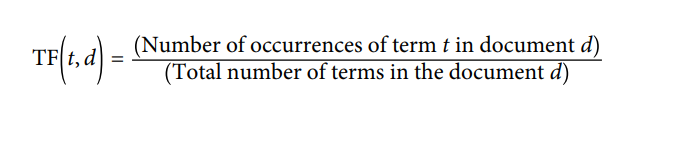

* <b>Inverse Document Frequency(IDF)</b>: This is term that measures how important that word is in the entire set of documents(also know as corpus) that we are considering.  While we calculate TF, all words are given equal importance, however in the entire corpus, how important the word is determined by this IDF term. The common words like "the","and","was" are given less weightage, and words that rare in corpus(for eg: "Excellent","horrific") are given more weightage to pick up the importance

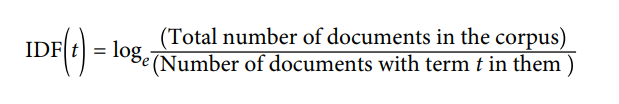

#### Thus, TF-IDF score = TF * IDF.

#### Now let's see the TF-IDF in action:

In [19]:
from collections import Counter
import numpy as np

In [20]:
# Creating a sample courpus with 4 sentences
sentence =["this is the first sentence",
        "this is the second sentence",
        "the third sentence is this one",
        "this is the fourth sentence and it is fantastic"
       ]

In [21]:
total_docs = len(sentence)
vocab = ' '.join(str(word).lower() for sent in sentence for word in sent.split())
word_count = Counter(vocab.split())

# Building a word list of unique words
word_set = list(set(vocab.split()))
print(word_set)

#Building a word to index mapping
word2idx={}
for idx,word in enumerate(word_set):
    word2idx[word]=idx

print(word2idx)

['fantastic', 'sentence', 'this', 'first', 'fourth', 'the', 'one', 'second', 'and', 'it', 'third', 'is']
{'fantastic': 0, 'sentence': 1, 'this': 2, 'first': 3, 'fourth': 4, 'the': 5, 'one': 6, 'second': 7, 'and': 8, 'it': 9, 'third': 10, 'is': 11}


In [22]:
def term_freq(sentence,word):
    """Function to compute the term frequency given a sentence and word
    
    #Arguments
        sentence: The sentence or the document that we are considering
        word: The word in the sentence for which we need to calculate term frequency
    #Returns
        Returns the term frequency
    """
    len_sen=len(sentence.split())
    frequency = len([token for token in sentence.split() if word==token])
    return frequency/len_sen

In [23]:
def idf(word):
    """Function to calculate the IDF of the document corpus
    
    #Arguments:
        word : The word for which we need to calculate the IDF
    #Returns:
        The IDF value
    """
    doc_len=len(sentence)
    doc_count=0
    for sent in sentence:
        if word in sent:
            doc_count+=1
    return np.log(doc_len/doc_count)+1

In [24]:
# Building the vectore representation of TF-IDF
full_vec=[]
for sent in sentence:  
    vec = np.zeros(len(word_set)) 
    for word in sent.split():
        tfidf = term_freq(sent,word)*idf(word)
        vec[word2idx[word]]=tfidf
    full_vec.append(vec)

In [25]:
tfidf_df = pd.DataFrame(full_vec,index=['Sent1','Sent2','Sent3','Sent4'])
tfidf_df.columns=word_set
tfidf_df.style.background_gradient(cmap='Purples')

,fantastic,sentence,this,first,fourth,the,one,second,and,it,third,is
Sent1,0.000000,0.200000,0.200000,0.477259,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000
Sent2,0.000000,0.200000,0.200000,0.000000,0.000000,0.200000,0.000000,0.477259,0.000000,0.000000,0.000000,0.200000
Sent3,0.000000,0.166667,0.166667,0.000000,0.000000,0.166667,0.397716,0.000000,0.000000,0.000000,0.397716,0.166667
Sent4,0.265144,0.111111,0.111111,0.000000,0.265144,0.111111,0.000000,0.000000,0.265144,0.265144,0.000000,0.222222


#### The above representation shows the custom TF-IDF vectors of the corpus that we built. Note that the sklearn representation and the formula is slightly different, and hence the value you get if we do a TFIDF vectorization would be different. I have attached the reference below. But the basic idea remains the same

#### <b>Pros</b> 

* Same as BoW, the TFIDF also can be used to find the semantic similarity between sentences with euclidean or cosine similarity
* TFIDF is a better representation of the unique words in the text, as mentioned earlier

#### <b>Cons</b>

* Dimensionality increases with increasing words in the corpus, and the representations become sparse
* Similar to BoW, TFIDF cannot handle out of vocabulary(OOV) words

#### Well, to address the issues above such as OOV words, and sparse representations, continuous distributed representations of words were devised, and we would discuss that in the upcoming notebook, and much more in this series

#### <font color='red'> If you find this notebook useful, as a small token of appreciation, if you could upvote, it would be a big morale boost for me to continue with the same enthusiasm, for the upcoming NLP marvels

#### Note: I will keep updating the notebook based on your feedback, and for any corrections, please feel free to comment, I'd be happy to respond  :)

### <b> References </b>

#### <b> Books</b>

* Practical Natural Language Processing: A Comprehensive Guide to Building Real-World NLP Systems

#### <b> Articles</b>

* https://www.enjoyalgorithms.com/blog/word-vector-encoding-in-nlp
* https://www.nltk.org/book/
* https://towardsdatascience.com/tf-idf-for-document-ranking-from-scratch-in-python-on-real-world-dataset-796d339a4089#:~:text=TF%2DIDF%20stands%20for%20%E2%80%9CTerm,Information%20Retrieval%20and%20Text%20Mining.
* https://www.askpython.com/python/examples/bag-of-words-model-from-scratch
